In [1]:
from ghi_2020 import run_pipeline


/Users/rr/Documents/Diajeng/citi/timexer/TimeXer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  GHI FORECASTING — FEATURE SELECTION PIPELINE
[load_and_prep] Dropping 29 blocked columns:
   ✗ DCS002 Real Output Power
   ✗ DCS002 Real Irradiance
   ✗ Simulated Output Power from DCS002 Real Irradiance
   ✗ Simulated Power Generated
   ✗ Simulated DC Inverter Input
   ✗ Transmitted Plane Of Array Irradiance
   ✗ DHI
   ✗ Clearsky GHI
   ✗ Fill Flag
   ✗ Wind Direction
   ✗ Wind Speed
   ✗ Wx
   ✗ Wy
   ✗ Week of Year
   ✗ Day Number
   ✗ Year sin
   ✗ Year cos
   ✗ Day Length
   ✗ Apparent Zenith
   ✗ Zenith
   ✗ Apparent Elevation
   ✗ Elevation
   ✗ Azimuth
   ✗ Angle of Incidence
   ✗ Hour Angle
   ✗ Airmass Absolute
   ✗ Latitude
   ✗ Longitude
   ✗ Altitude

[load_and_prep] Remaining columns : 28
[load_and_prep] Period            : 2020-01-01 → 2020-12-31
[load_and_prep] Rows              : 52,704
✅ Features selected : 12
   Rows after dropna : 52,704

=== VIF Audit ===
                           VIF                        flag
Day cos              74.280079  🔴 HIGH — consider

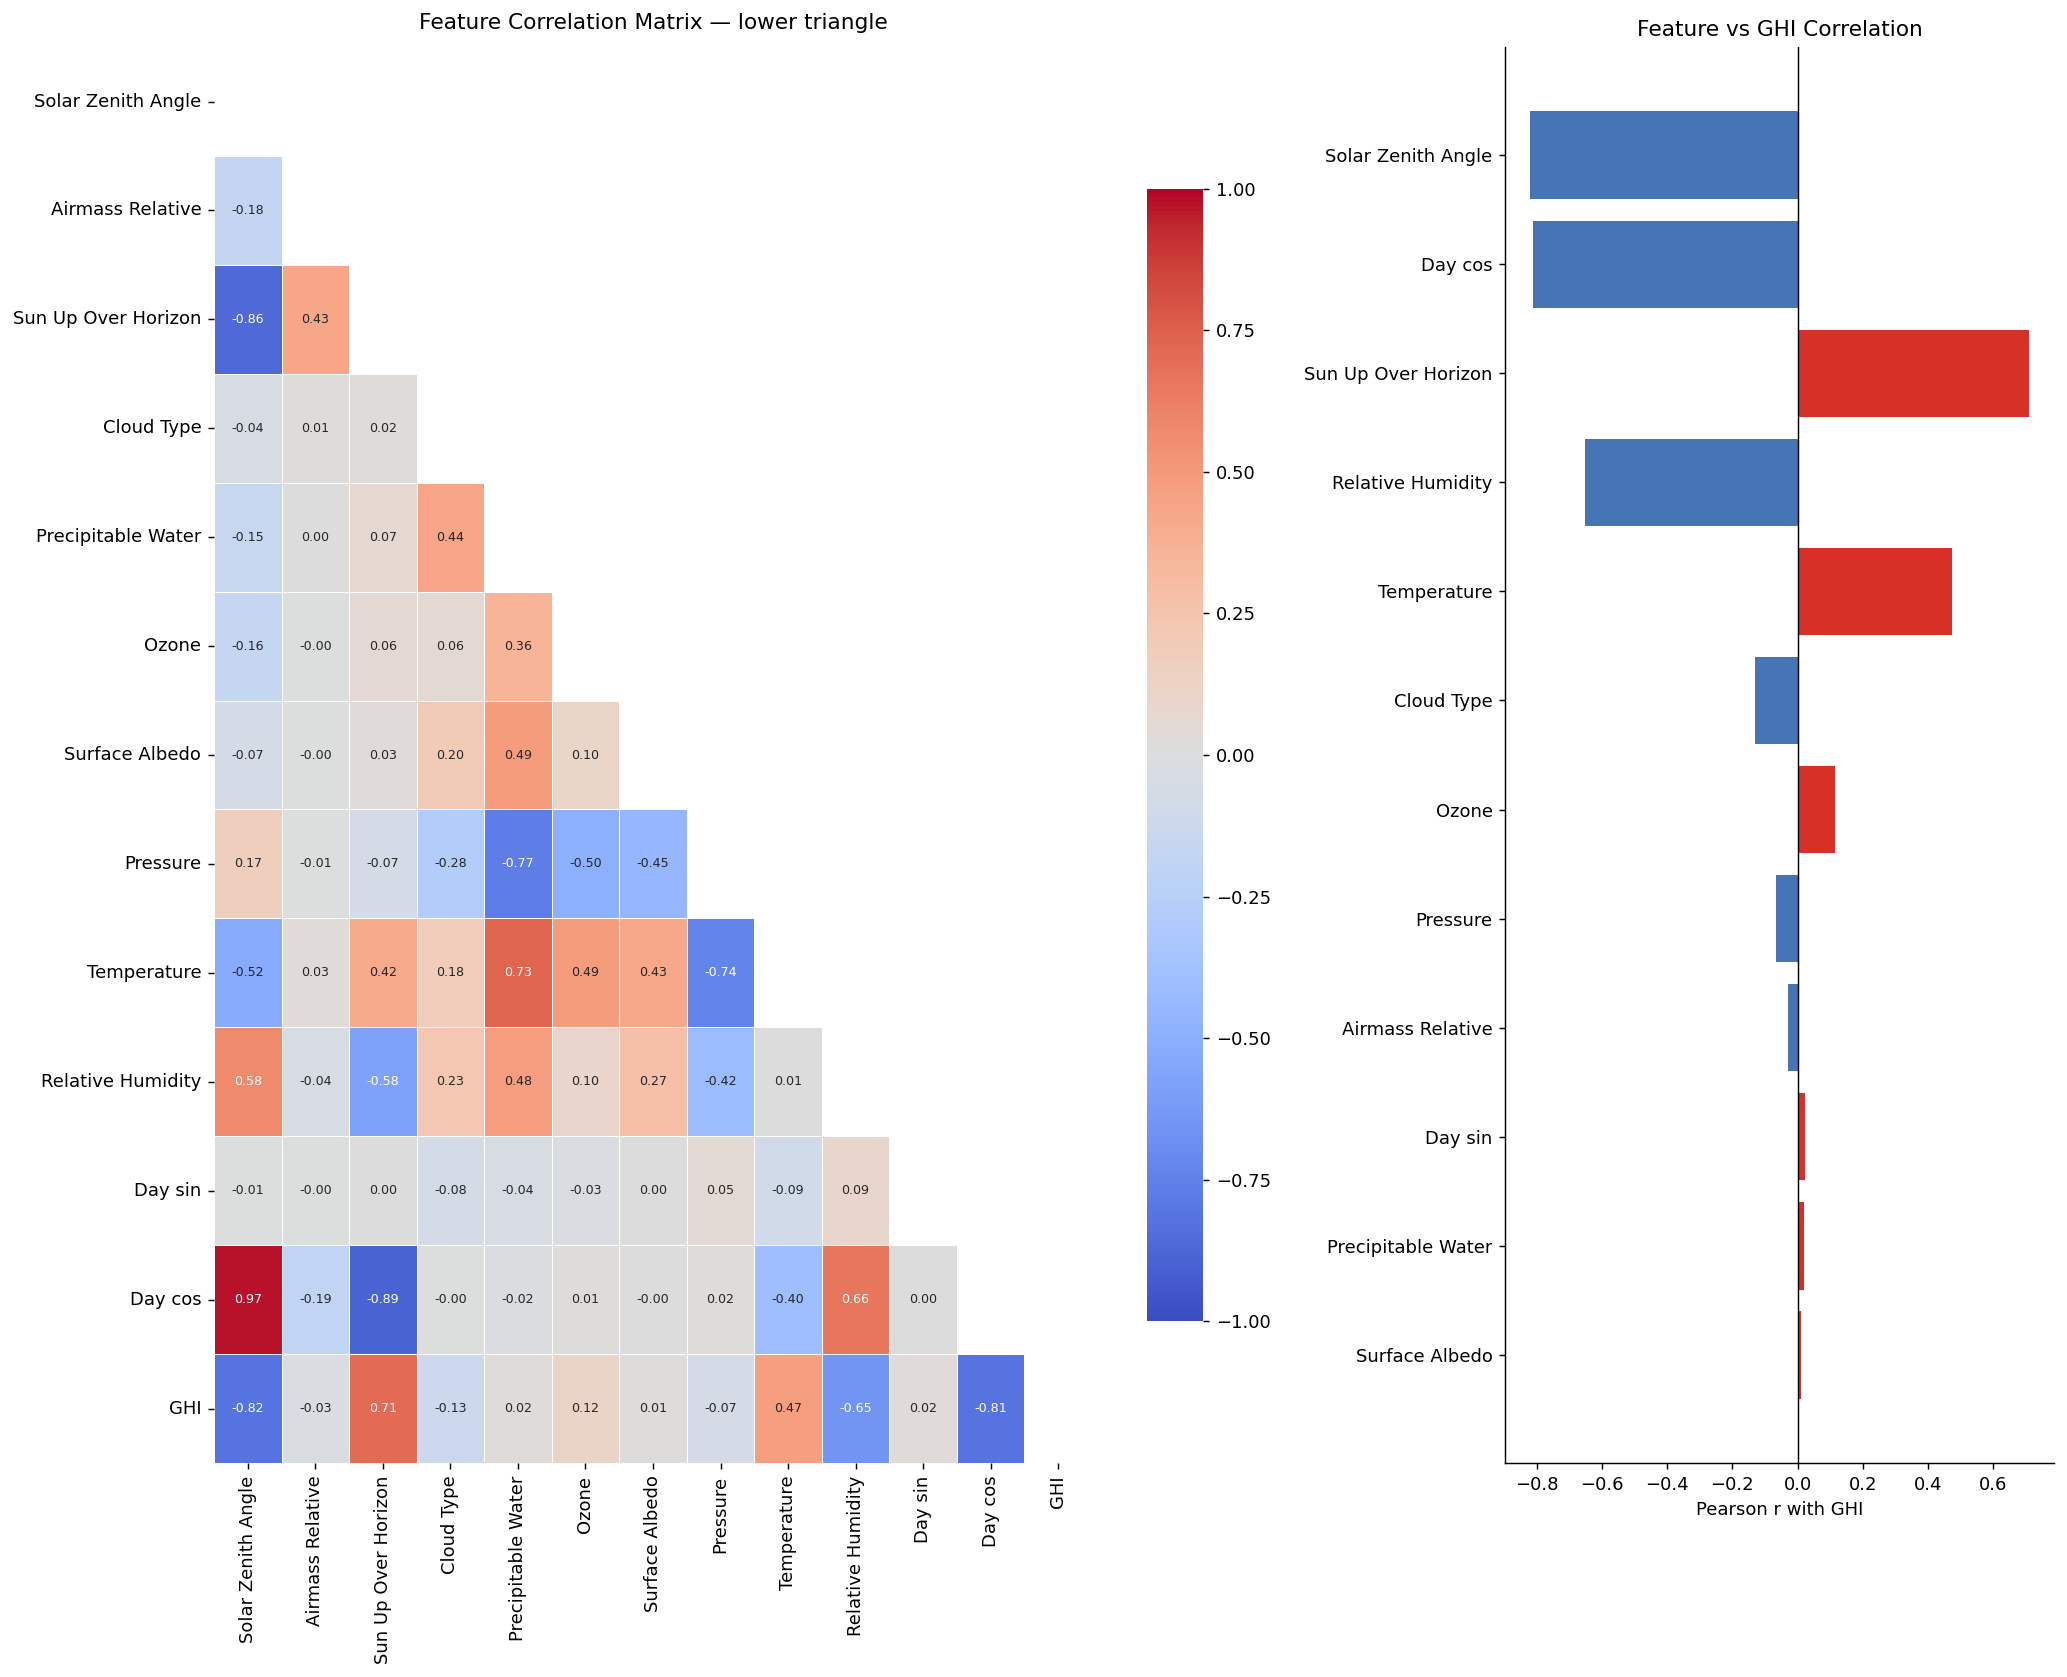

Saved → ./correlation_analysis.png
Train: (42163, 12)  2020-01-01 → 2020-10-19
Test : (10541, 12)   2020-10-19 → 2020-12-31

[Training Random Forest …]
[Training XGBoost …]

Random Forest — Test Metrics
  RMSE: 51.7897
  MAE: 19.7907
  R²: 0.9493

XGBoost — Test Metrics
  RMSE: 52.3038
  MAE: 23.6533
  R²: 0.9483

[Computing feature importances + SHAP …]

=== Combined Importance Table ===
                     RF_MDI  XGB_gain  RF_permutation  RF_SHAP  XGB_SHAP
Solar Zenith Angle   0.6275    0.4588          1.2508 171.4017  179.7812
Cloud Type           0.0956    0.0682          0.2127  52.5774   47.2126
Day cos              0.1644    0.2748          0.0541  44.9389   35.8718
Airmass Relative     0.0548    0.0446          0.0874  27.9120   19.7390
Sun Up Over Horizon  0.0218    0.1159          0.0057  11.6777    1.5590
Temperature          0.0091    0.0085          0.0095   8.6009   14.7742
Relative Humidity    0.0078    0.0050          0.0032   2.6433    3.6540
Precipitable Water   0.0

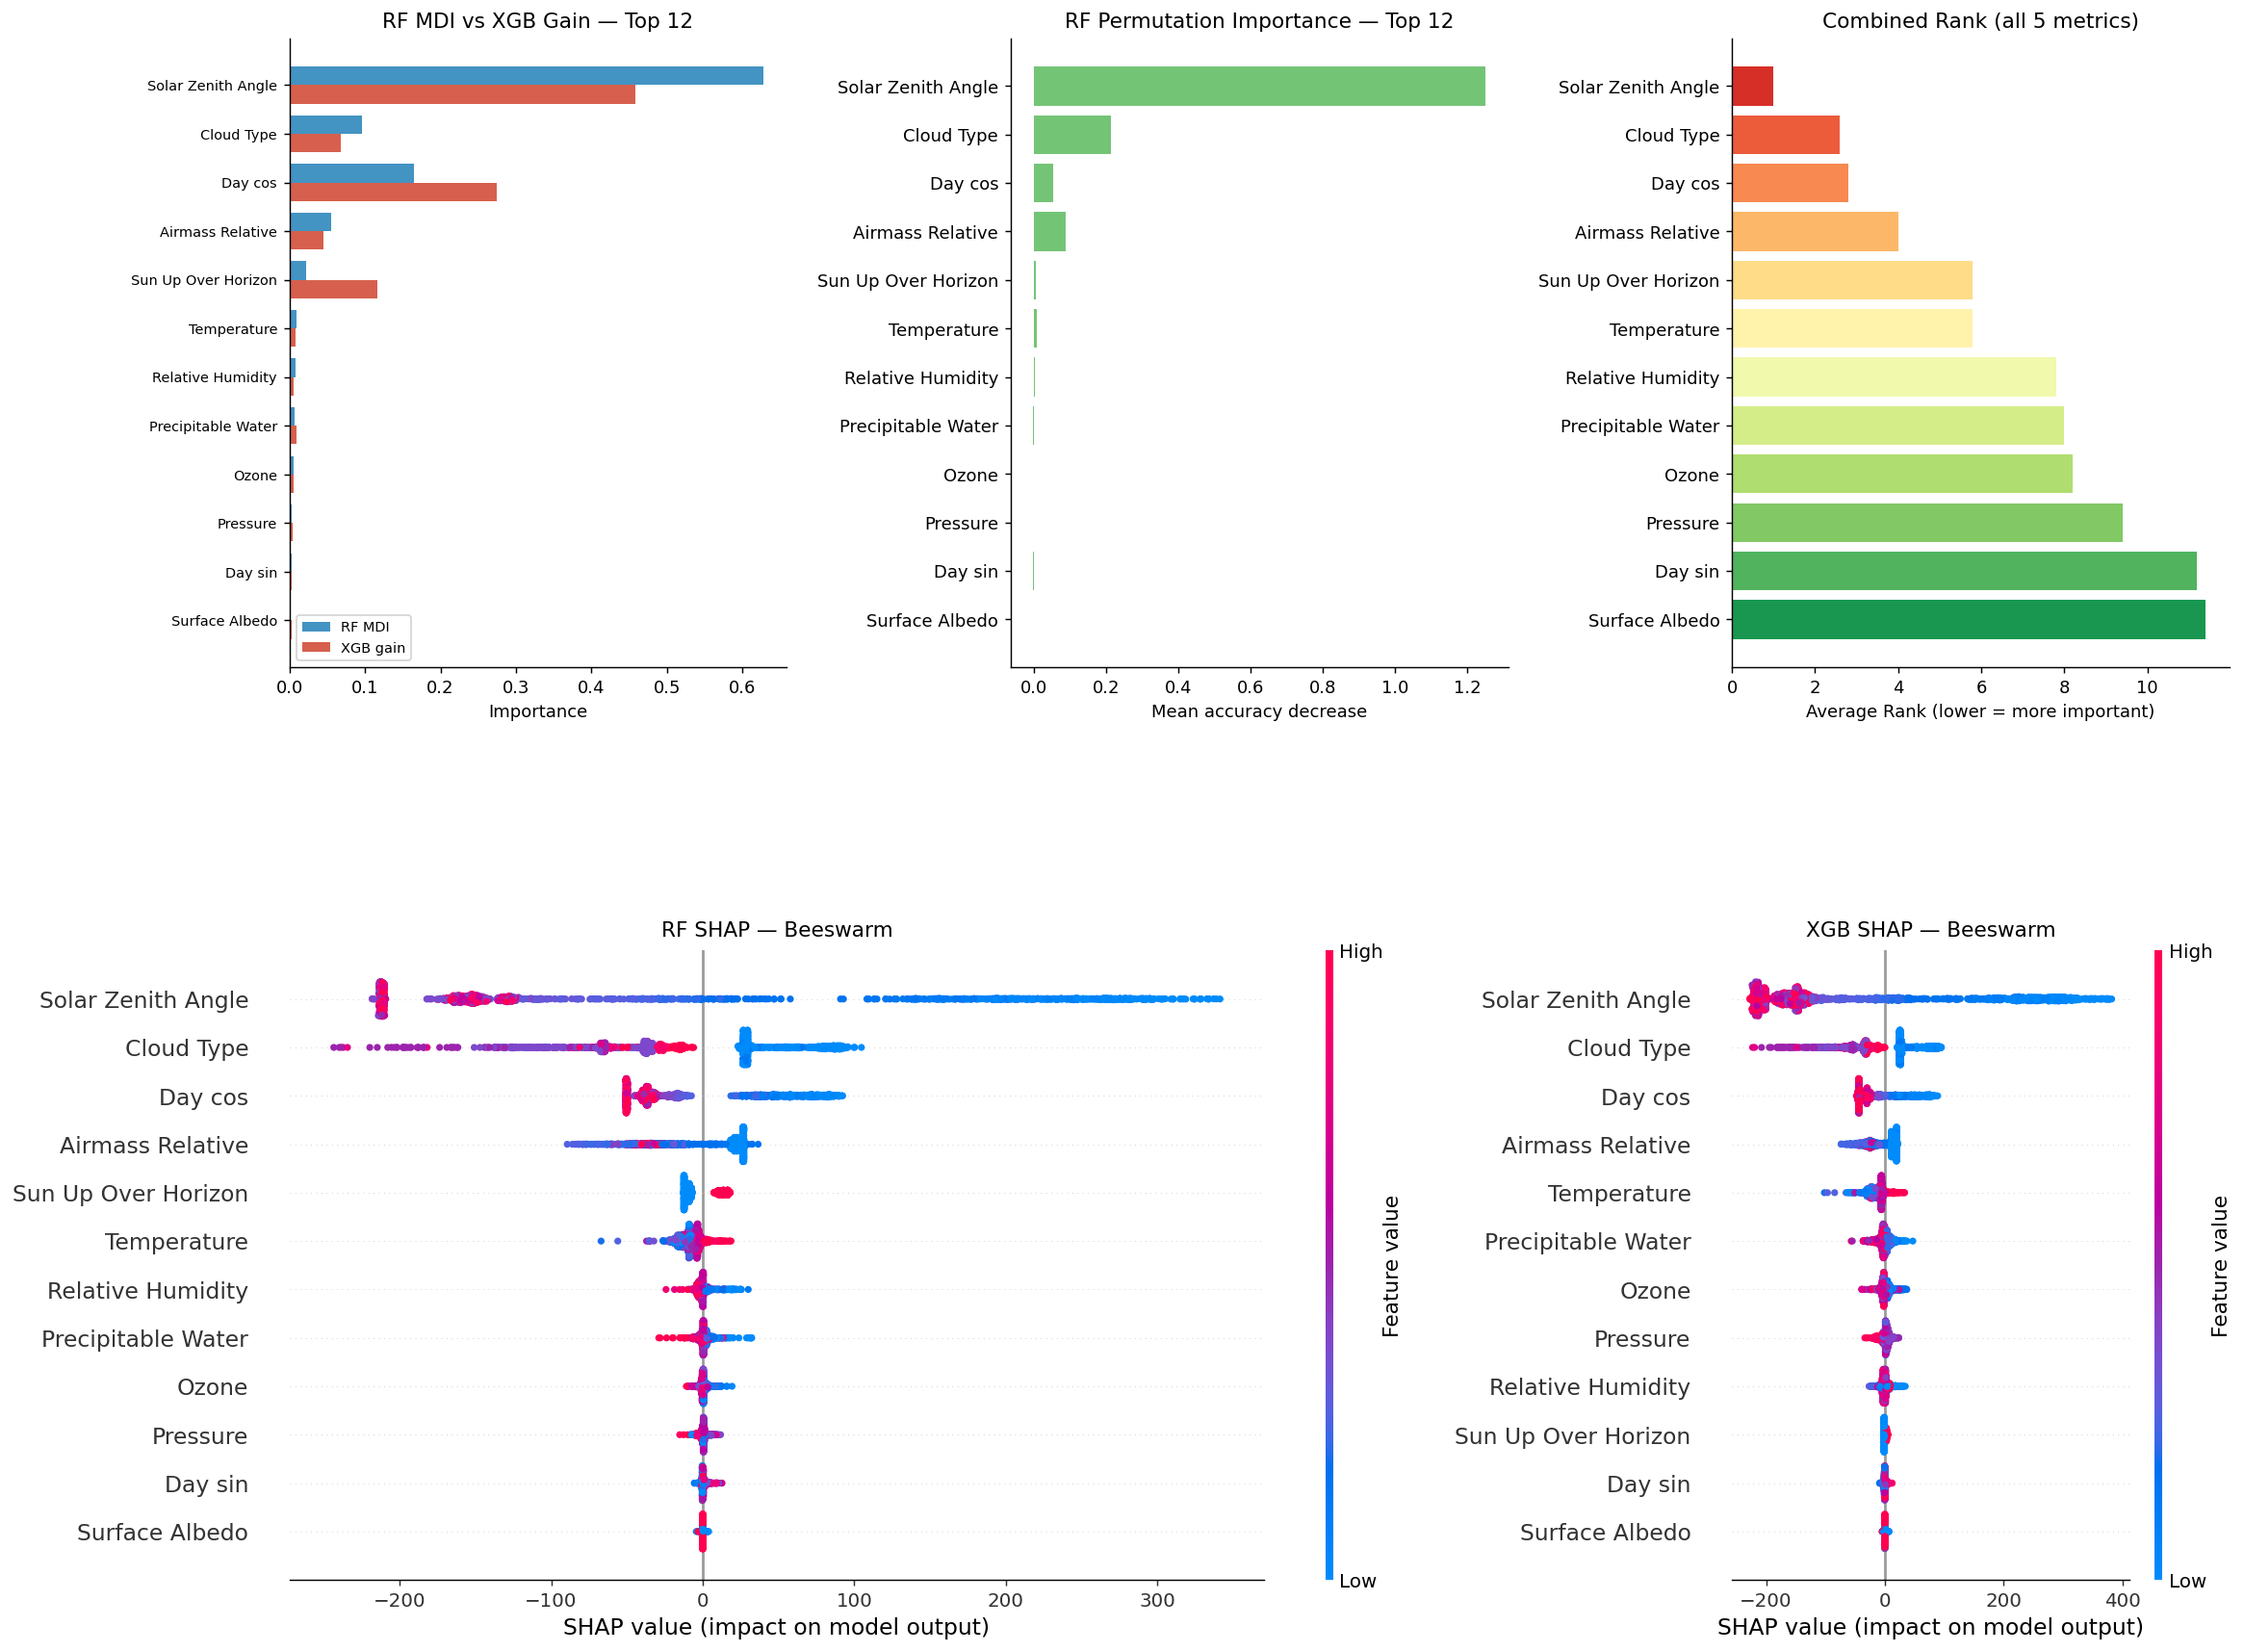

Saved → ./feature_importance_dashboard.png
ℹ  Added 'Day sin' to preserve Day sin/cos pair

Final 11 features selected:
   1. Solar Zenith Angle                            avg_rank=1.0
   2. Cloud Type                                    avg_rank=2.6
   3. Day cos                                       avg_rank=2.8
   4. Airmass Relative                              avg_rank=4.0
   5. Sun Up Over Horizon                           avg_rank=5.8
   6. Temperature                                   avg_rank=5.8
   7. Relative Humidity                             avg_rank=7.8
   8. Precipitable Water                            avg_rank=8.0
   9. Ozone                                         avg_rank=8.2
  10. Pressure                                      avg_rank=9.4
  11. Day sin                                       avg_rank=11.2

✅ Exported: ./ghi_kaohsiung_dcs2_2020_final.csv
   Shape  : (52704, 13)
   Columns: ['date', 'Solar Zenith Angle', 'Cloud Type', 'Day cos', 'Airmass Relative', 'Su

In [2]:
results = run_pipeline(
    csv_path    = ".././dataset/forPaper/Kaohsiung_DCS002_All_10_Minutely.csv",
    year        = 2020,
    top_n       = 10,
    output_path = "./ghi_kaohsiung_dcs2_2020_final.csv",
)
importance_table = results["importance_table"]
forecast_df      = results["forecast_df"]